In [7]:
%pip install -q numpy
%pip install -q matplotlib

import numpy as np
import matplotlib.pyplot as plt

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [8]:
def complex_inner_product(u, v):
    total = 0
    for n in range(len(u)):
        total = total + u[n] * np.conj(v[n])
    return total

def generate_basis_vector(k, p):
    w0 = 2 * np.pi / p
    psi = np.zeros(p, dtype=complex)
    for n in range(p):
        psi[n] = np.exp(1j * w0 * n * k)
    return psi

In [9]:
def generate_signal(p, frequencies, amplitudes):
    s = np.zeros(p)
    for n in range(p):
        t_n = n / p
        value = 0
        for j in range(len(frequencies)):
            value = value + amplitudes[j] * np.cos(2 * np.pi * frequencies[j] * t_n)
        s[n] = value
    return s

s = generate_signal(64, [2, 8], [2.0, 0.5])

In [10]:
def get_projection_coefficient(signal, k, p):
    psi_k = generate_basis_vector(k, p)
    return complex_inner_product(signal, psi_k) / complex_inner_product(psi_k, psi_k)

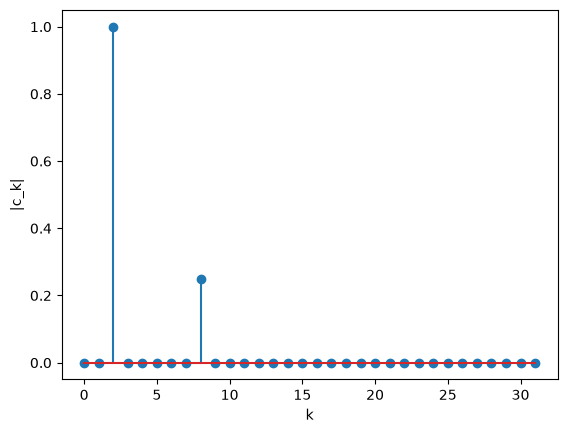

In [11]:
mags = []
for k in range(0, 32):
    mags.append(abs(get_projection_coefficient(s, k, 64)))
plt.stem(range(32), mags)
plt.xlabel("k"); plt.ylabel("|c_k|")
plt.show()

In [12]:
s2 = generate_signal(64, [24, 26], [1, 1])